# ETF Arbitrage Demo (Standalone Engine + yfinance)

This notebook is an **interview-ready**, fully runnable demo:
- Downloads price data with **yfinance** (and caches locally).
- Implements a small but complete **backtest engine** (positions, cash, PnL, trade log, costs).
- Runs **two versions** of the ETF arbitrage idea:
  1) **Baseline (Capula assignment style)**: synthetic ETF from *rebased components* and trade on divergence.
  2) **Improved**: z-score entry/exit, dollar-neutral sizing, risk controls.

> Tip: Run cells top-to-bottom. If yfinance rate-limits or errors, rerun the download cell or extend the date range.


In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from datetime import date
import warnings

# Suppress pandas warnings for a cleaner demo
warnings.filterwarnings('ignore')

class TradingEngine:
    def __init__(self, initial_capital=100000.0, commission_bps=0.0001):
        self.cash = initial_capital
        self.initial_capital = initial_capital
        self.commission_bps = commission_bps
        self.positions = {} # {ticker: {'qty': 0, 'avg_price': 0.0}}
        self.history = []
        self.equity_curve = [] # Track daily portfolio value

    def get_portfolio_value(self, current_prices):
        """Returns Cash + Market Value of Positions"""
        market_value = 0.0
        for ticker, pos in self.positions.items():
            if ticker in current_prices:
                market_value += pos['qty'] * current_prices[ticker]
        return self.cash + market_value

    def execute_order(self, ticker, qty, price, date, action_label):
        """
        Handles Buy/Sell logic including Cash deduction and WAP updates.
        """
        if qty == 0: return

        # 1. Calculate Cost & Commission
        notional = abs(qty * price)
        comm = notional * self.commission_bps
        
        # 2. Update Cash (The "Fix")
        # Buying = Cash Outflow, Selling = Cash Inflow
        self.cash -= (qty * price) 
        self.cash -= comm
        
        # 3. Update Position State
        current_pos = self.positions.get(ticker, {'qty': 0, 'avg_price': 0.0})
        curr_qty = current_pos['qty']
        
        # Check if we are adding or reducing/flipping
        is_same_direction = (curr_qty * qty) > 0 or curr_qty == 0
        
        if is_same_direction:
            # SCALING IN: Update Weighted Average Price
            new_total_qty = curr_qty + qty
            old_notional = curr_qty * current_pos['avg_price']
            new_trade_notional = qty * price
            
            # Avoid division by zero
            new_avg_price = price
            if new_total_qty != 0:
                new_avg_price = (old_notional + new_trade_notional) / new_total_qty
            
            self.positions[ticker] = {'qty': new_total_qty, 'avg_price': new_avg_price}
            
        else:
            # REDUCING / FLIPPING: Realize PnL? 
            # For this simple engine, we just update the quantity. 
            # A full engine would calculate Realized PnL here.
            new_total_qty = curr_qty + qty
            if new_total_qty == 0:
                if ticker in self.positions: del self.positions[ticker]
            else:
                # If we flipped (e.g. +10 to -10), avg price resets to current price
                # If we just reduced (+10 to +5), avg price stays same
                is_flip = (curr_qty * new_total_qty) < 0
                new_avg_price = price if is_flip else current_pos['avg_price']
                self.positions[ticker] = {'qty': new_total_qty, 'avg_price': new_avg_price}

        # 4. Log Trade
        self.history.append({
            'date': date, 'ticker': ticker, 'action': action_label,
            'qty': qty, 'price': price, 'comm': comm
        })

        
# ==========================================
# 2. DATA GENERATOR (Robust Handling)
# ==========================================
def get_aligned_market_data():
    """
    Fetches target etf and its underlying components 
    """
    tickers = ['XOM', 'CVX', 'EOG', 'SLB', 'COP']
    etf_ticker = 'XLE' 
    
    print(f"Downloading data for {len(tickers)} stocks + {etf_ticker}...")
    
    # Download all
    data = yf.download(tickers + [etf_ticker], start="2015-01-01", end=date.today(), progress=False)['Close']
    
    # CRITICAL: Drop rows where ANY stock is missing. 
    # This automatically finds the common start date (likely Sept 2020 due to PLTR).
    data = data.dropna()
    
    # Rename ETF column for strategy logic
    data.rename(columns={etf_ticker: 'ETF_PROXY'}, inplace=True)
    
    print(f"Simulation Range: {data.index.min().date()} to {data.index.max().date()}")
    print(f"Total Trading Days: {len(data)}")
    return data

# ==========================================
# 3. STRATEGY LOGIC (The "Student" Code)
# ==========================================
def run_arbitrage_strategy(prices_df, engine, date):
    # Separate ETF from Components
    tickers = prices_df.columns.tolist()
    etf_col = "ETF_PROXY"
    components = [t for t in tickers if t != etf_col]

    # 1. Define Reference Point (t0) for normalization
    # In a real strategy, this might be a rolling window, but here we use start-of-period
    prices_t0 = prices_df.iloc[0]
    current_prices = prices_df.loc[date]
    
    # 2. Compute Synthetic ETF Value (Normalized to 100)
    # logic: If AAPL went 100->110, it contributes 110 to the index
    rebased_components = (current_prices[components] / prices_t0[components]) * 100
    syn_etf_value = rebased_components.mean()
    
    # 3. Compute Real ETF Value (Normalized to 100)
    # We MUST normalize the real ETF too, otherwise we compare Price ($300) vs Index (100)
    real_etf_raw_price = current_prices[etf_col]
    real_etf_normalized = (real_etf_raw_price / prices_t0[etf_col]) * 100
    
    # 4. Calculate Spread
    spread = real_etf_normalized - syn_etf_value
    
    # 5. Trading Parameters
    threshold = 2.0  # Divergence threshold (e.g., 2% difference)
    etf_vol = 200    # Volume to trade
    stock_vol = 20   # Volume per stock (approx hedge ratio)

    try:
        # Check current exposure
        current_pos_vol = 0
        if etf_col in engine.current_positions:
            current_pos_vol = engine.current_positions[etf_col].position_volume
        
        # --- Signal Generation ---
        
        # Case A: Real ETF is Cheap (Undervalued vs Synthetic) -> BUY ETF, SELL Basket
        if spread < -threshold:
            if current_pos_vol <= 0: # Only enter if flat or short
                engine.execute_order(etf_col, etf_vol, "BUY", date, real_etf_raw_price)
                for t in components:
                    engine.execute_order(t, stock_vol, "SELL", date, current_prices[t])
                    
        # Case B: Real ETF is Expensive (Overvalued vs Synthetic) -> SELL ETF, BUY Basket
        elif spread > threshold:
            if current_pos_vol >= 0: # Only enter if flat or long
                engine.execute_order(etf_col, etf_vol, "SELL", date, real_etf_raw_price)
                for t in components:
                    engine.execute_order(t, stock_vol, "BUY", date, current_prices[t])

    except Exception as e:
        print(f"Error on {date}: {e}")



In [51]:
## strategy improvement using z score to get a statistical score of divergence instead of an absolute deviation. 

def run_z_score_backtest(data, engine, window=60, entry_z=2.0, exit_z=0.5 ):
    
    # --- STEP A: PRE-CALCULATE SIGNALS (Vectorized Speed) ---
    rets = np.log(data / data.shift(1))
    etf_col = 'ETF_PROXY'
    components = [c for c in rets.columns if c != etf_col]
    
    basket_ret = rets[components].mean(axis=1)
    etf_ret = rets[etf_col]
    
    # Rolling Beta & Z-Score
    rolling_cov = etf_ret.rolling(window).cov(basket_ret)
    rolling_var = basket_ret.rolling(window).var()
    rolling_beta = rolling_cov / rolling_var
    
    spread_ret = etf_ret - (rolling_beta * basket_ret)
    z_score = (spread_ret - spread_ret.rolling(window).mean()) / spread_ret.rolling(window).std()

    plt.figure(figsize = (12,8))
    plt.plot(data.index, z_score, label= "z score time series", linewidth = 1.5) 
    plt.show() 

    # --- STEP B: PARAMETERS ---
    capital_per_trade = 20000.0 
    
    # --- STEP C: THE LOOP ---
    print(f"Strategy started with Cash: ${engine.cash:,.2f}")
    
    dates = data.index
    for i in range(window, len(dates)):
        today = dates[i]
        yesterday = dates[i-1] 
        
        # 1. Get Signal
        z_val = z_score.loc[yesterday]
        beta_val = rolling_beta.loc[yesterday]
        
        if np.isnan(z_val) or np.isnan(beta_val): continue
            
        today_prices = data.loc[today]
        current_pos_qty = engine.positions.get(etf_col, {}).get('qty', 0)
        
        # 2. Trading Logic (Same logic, using the passed 'engine')
        
        # ENTRY: Long Spread
        if z_val < -entry_z and current_pos_qty <= 0:
            if current_pos_qty < 0:
                engine.execute_order(etf_col, -current_pos_qty, today_prices[etf_col], today, "CLOSE_SHORT")
                for t in components:
                    p_qty = engine.positions.get(t, {}).get('qty', 0)
                    if p_qty != 0: engine.execute_order(t, -p_qty, today_prices[t], today, "CLOSE_HEDGE")
            
            qty_etf = capital_per_trade / today_prices[etf_col]
            engine.execute_order(etf_col, qty_etf, today_prices[etf_col], today, "BUY_ETF")
            
            hedge_amt = capital_per_trade * beta_val
            qty_per_stock = -1 * (hedge_amt / len(components))
            for t in components:
                engine.execute_order(t, qty_per_stock / today_prices[t], today_prices[t], today, "SELL_BASKET")

        # ENTRY: Short Spread
        elif z_val > entry_z and current_pos_qty >= 0:
            if current_pos_qty > 0:
                engine.execute_order(etf_col, -current_pos_qty, today_prices[etf_col], today, "CLOSE_LONG")
                for t in components:
                    p_qty = engine.positions.get(t, {}).get('qty', 0)
                    if p_qty != 0: engine.execute_order(t, -p_qty, today_prices[t], today, "CLOSE_HEDGE")
            
            qty_etf = -1 * (capital_per_trade / today_prices[etf_col])
            engine.execute_order(etf_col, qty_etf, today_prices[etf_col], today, "SELL_ETF")
            
            hedge_amt = capital_per_trade * beta_val
            qty_per_stock = (hedge_amt / len(components))
            for t in components:
                engine.execute_order(t, qty_per_stock / today_prices[t], today_prices[t], today, "BUY_BASKET")

        # EXIT: Mean Reversion
        elif abs(z_val) < exit_z and current_pos_qty != 0:
            engine.execute_order(etf_col, -current_pos_qty, today_prices[etf_col], today, "EXIT_ETF")
            for t in components:
                p_qty = engine.positions.get(t, {}).get('qty', 0)
                if p_qty != 0: engine.execute_order(t, -p_qty, today_prices[t], today, "EXIT_HEDGE")
        
        # 3. Mark-to-Market
        engine.equity_curve.append({'date': today, 'equity': engine.get_portfolio_value(today_prices)})

    return pd.DataFrame(engine.equity_curve).set_index('date')

    print(z_score)
   
def check_spread (prices_df): 
    tickers = prices_df.columns.tolist()
    etf_col = "ETF_PROXY"
    components = [t for t in tickers if t != etf_col]

    daily_rets = prices_df.pct_change()
    
    # 2. Create Synthetic Basket Return (Equal Weight approximation)
    basket_ret = daily_rets[components].mean(axis=1)
    etf_ret = daily_rets[etf_col]
    
    # 3. Create the Spread of RETURNS (Stationary!)
    # Spread = ETF Return - Basket Return
    spread_ret = etf_ret - basket_ret

    plt.figure(figsize=(16,12))
    plt.plot(daily_rets.index, spread_ret, label = "spread check", linewidth = 1.5)
    plt.show()





Simulation Range: 2015-01-02 to 2026-01-20
Total Trading Days: 2778
Ticker            COP        CVX        EOG        SLB  ETF_PROXY        XOM
Date                                                                        
2015-01-02  48.290165  70.209557  66.832115  62.903400  25.714989  57.916893
2015-01-05  45.991955  67.403152  62.803631  61.199959  24.651207  56.332195
2015-01-06  44.093140  67.372002  61.013988  60.003109  24.289066  56.032711
2015-01-07  44.387421  67.315880  60.629982  59.995770  24.340799  56.600487
2015-01-08  45.494476  68.856239  62.948524  60.722702  24.887239  57.542568
Check Spread: 


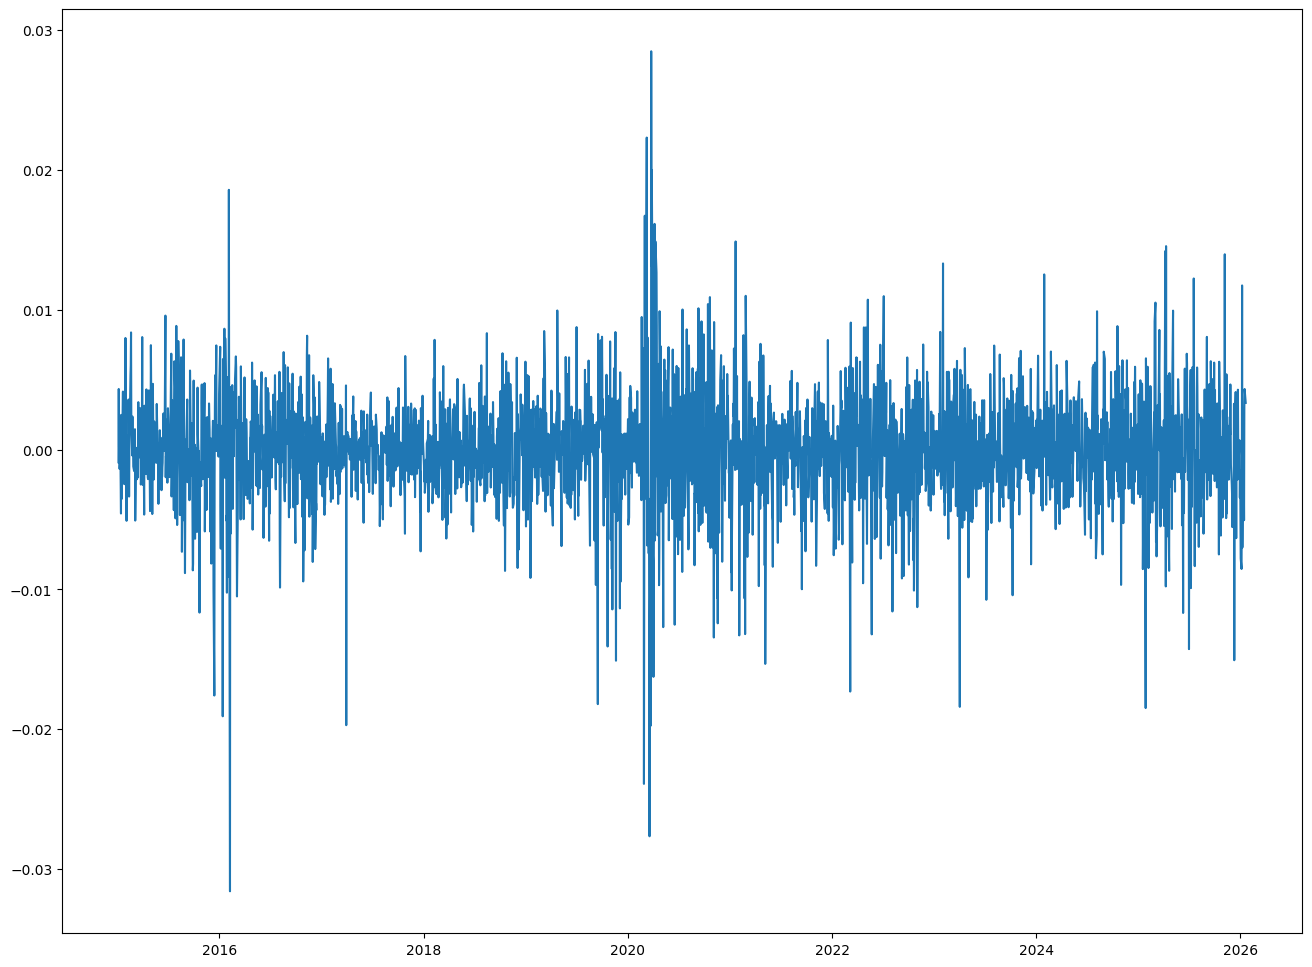

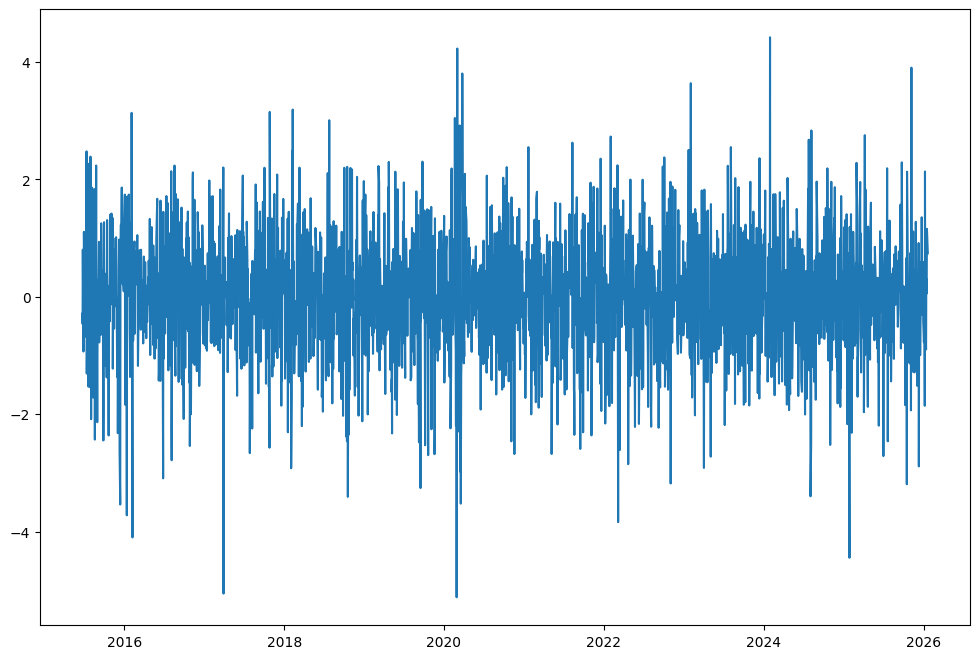

Strategy started with Cash: $100,000.00
Final Cash Balance: $102,408.69
Final PnL: $2,408.69


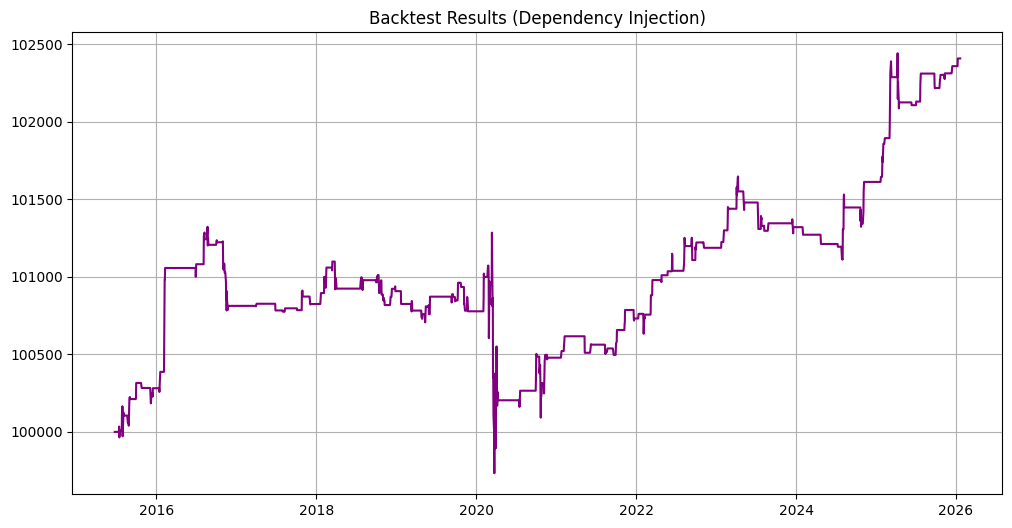

In [52]:

df = get_aligned_market_data()
print(df.head())
dates = df.index 


print("Check Spread: ")
check_spread(df)

engine = TradingEngine(initial_capital= 100000, commission_bps=0)

equity_df = run_z_score_backtest(df, engine, window=60, entry_z=2.0)

# 4. Results
print(f"Final Cash Balance: ${engine.cash:,.2f}")
print(f"Final PnL: ${(engine.equity_curve[-1]['equity'] - 100000):,.2f}")

plt.figure(figsize=(12, 6))
plt.plot(equity_df['equity'], label='Portfolio Value', color='purple')
plt.title('Backtest Results (Dependency Injection)')
plt.grid(True)
plt.show()